   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.6 MB/s eta 0:00:00


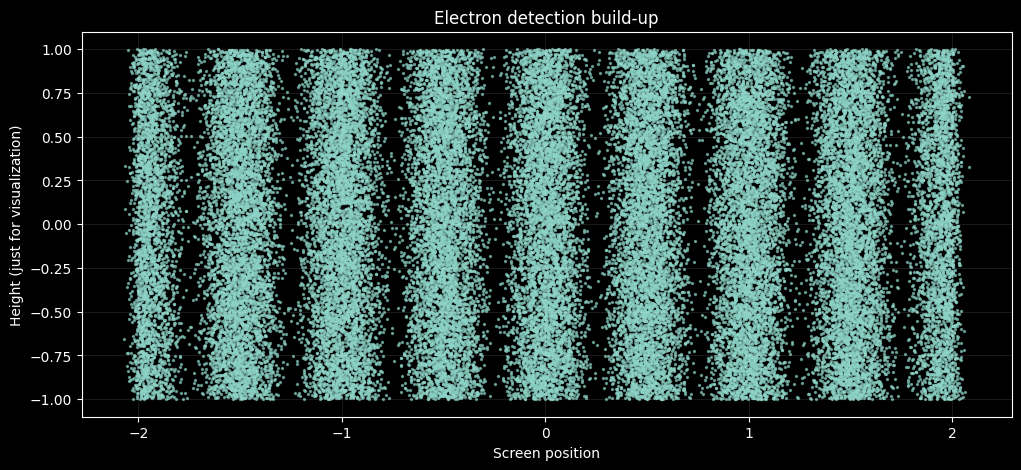

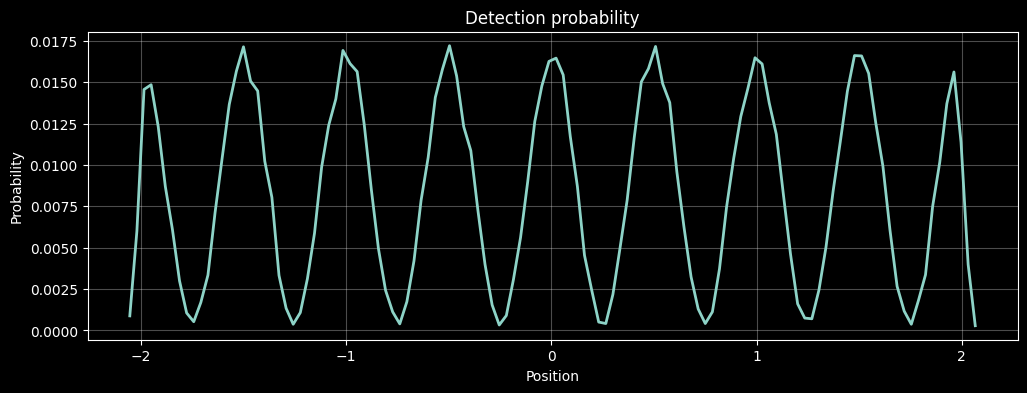

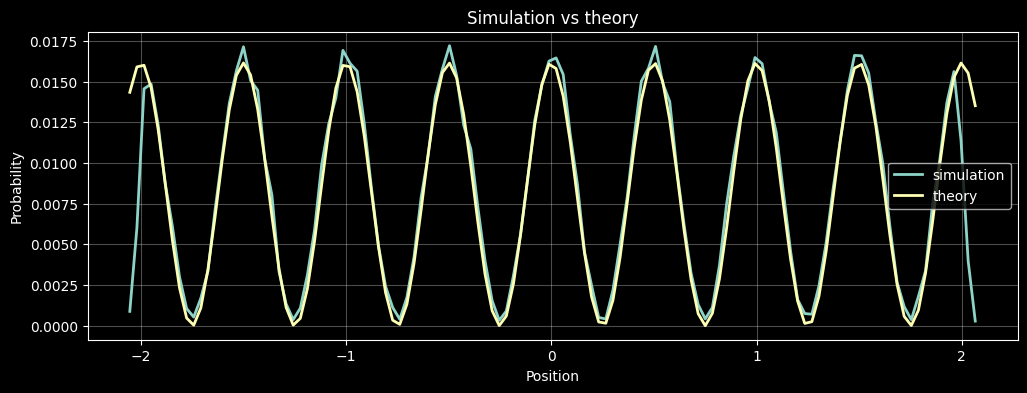

In [1]:
!pip install qiskit qiskit-aer -q

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator


# --- basic setup ---

points = 180
shots = 500
noise = 0.025

# physical params (kept simple)
slit_gap = 1.0
lam = 0.5
screen_dist = 1.0

x_vals = np.linspace(-2, 2, points)
angles = (2 * np.pi * slit_gap / (lam * screen_dist)) * x_vals

sim = AerSimulator()

x_detected = []
y_detected = []


# --- simulate one electron at a time ---

for idx in range(len(angles)):

    ang = angles[idx]

    circuit = QuantumCircuit(1, 1)

    # put electron in superposition (both slits)
    circuit.h(0)

    # add phase depending on position
    circuit.rz(ang, 0)

    # recombine paths (interference step)
    circuit.h(0)

    # measure -> did it hit here or not
    circuit.measure(0, 0)

    compiled_circuit = transpile(circuit, sim)
    res = sim.run(compiled_circuit, shots=shots).result()

    data = res.get_counts()

    # how many electrons landed here
    hit_count = data.get('0', 0)

    # spread a bit so it looks like a real screen
    xs = np.random.normal(x_vals[idx], noise, hit_count)
    ys = np.random.uniform(-1, 1, hit_count)

    x_detected.extend(xs)
    y_detected.extend(ys)


# --- build-up pattern (like real experiment) ---

plt.style.use('dark_background')

plt.figure(figsize=(12, 5))
plt.scatter(x_detected, y_detected, s=2, alpha=0.6)

plt.title("Electron detection build-up")
plt.xlabel("Screen position")
plt.ylabel("Height (just for visualization)")

plt.grid(alpha=0.1)
plt.show()


# --- probability distribution from detections ---

hist, edges = np.histogram(x_detected, bins=120)

prob = hist / np.sum(hist)

centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(12, 4))
plt.plot(centers, prob, linewidth=2)

plt.title("Detection probability")
plt.xlabel("Position")
plt.ylabel("Probability")

plt.grid(alpha=0.3)
plt.show()


# --- compare with theory ---

theta_vals = (2 * np.pi * slit_gap / (lam * screen_dist)) * centers
expected = np.cos(theta_vals / 2) ** 2

# normalize so comparison is fair
expected = expected / np.sum(expected)

plt.figure(figsize=(12, 4))

plt.plot(centers, prob, label="simulation", linewidth=2)
plt.plot(centers, expected, label="theory", linewidth=2)

plt.legend()
plt.xlabel("Position")
plt.ylabel("Probability")
plt.title("Simulation vs theory")

plt.grid(alpha=0.3)
plt.show()